<a href="https://colab.research.google.com/github/lucasalechilet/Curso_FCD/blob/main/metricas_de_desempe%C3%B1o_modelo_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Métricas de Desempeño: Regresión Lineal


## 1. Importación de librerías y carga de datos

In [4]:
#link github https://github.com/lucasalechilet/Curso_FCD/blob/main/metricas_de_desempe%C3%B1o_modelo_regresion.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset proporcionado por el cliente
data = {
    'Antigüedad': [5, 3, 7, 2],
    'Kilometraje': [50000, 30000, 70000, 25000],
    'Puertas':    [4, 2, 4, 2],
    'Precio':     [12000, 15000, 9000, 16000]
}

df = pd.DataFrame(data)  #se genera el dataframe en base a los datos
print(df)

   Antigüedad  Kilometraje  Puertas  Precio
0           5        50000        4   12000
1           3        30000        2   15000
2           7        70000        4    9000
3           2        25000        2   16000


## 2. División en conjuntos de entrenamiento y prueba (80% - 20%)

In [2]:
X = df[['Antigüedad', 'Kilometraje', 'Puertas']] #se definen variables independientes
y = df['Precio']                                #se define variable dependiente


X_train, X_test, y_train, y_test = train_test_split(  # Con solo 4 registros, 80/20 resulta en 3 train y 1 test
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_train)} muestras")
print(f"Prueba:        {len(X_test)} muestras")

Entrenamiento: 3 muestras
Prueba:        1 muestras


## 3. Entrenamiento del modelo y predicciones

In [3]:
modelo = LinearRegression()
modelo.fit(X_train, y_train) #se realiza el entrenamiento usando las datos de entrenamiento

# Predicciones sobre todo el dataset para evaluar el comportamiento general
y_pred_all = modelo.predict(X)
y_pred_test = modelo.predict(X_test)

print("ccoeficientes:")
for feat, coef in zip(X.columns, modelo.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"intercepto: {modelo.intercept_:.4f}")

ccoeficientes:
  Antigüedad: -29.4118
  Kilometraje: -0.1471
  Puertas: -117.6471
intercepto: 19970.5882


## 4. Cálculo de métricas de desempeño


In [ ]:
mae  = mean_absolute_error(y, y_pred_all)
mse  = mean_squared_error(y, y_pred_all)
rmse = np.sqrt(mse)
r2   = r2_score(y, y_pred_all)      #se calcula el desempeño sobre todos los datos usando las distintas métricas

print(f"MAE  (Error Absoluto Medio):       ${mae:,.2f}")
print(f"MSE  (Error Cuadrático Medio):     ${mse:,.2f}")
print(f"RMSE (Raíz del ECM):               ${rmse:,.2f}")
print(f"R²   (Coeficiente de determinación): {r2:.4f}")

MAE  (Error Absoluto Medio):       $58.82
MSE  (Error Cuadrático Medio):     $13,840.83
RMSE (Raíz del ECM):               $117.65
R²   (Coeficiente de determinación): 0.9982


## 5. Gráfico comparativo: Precios reales vs. predichos

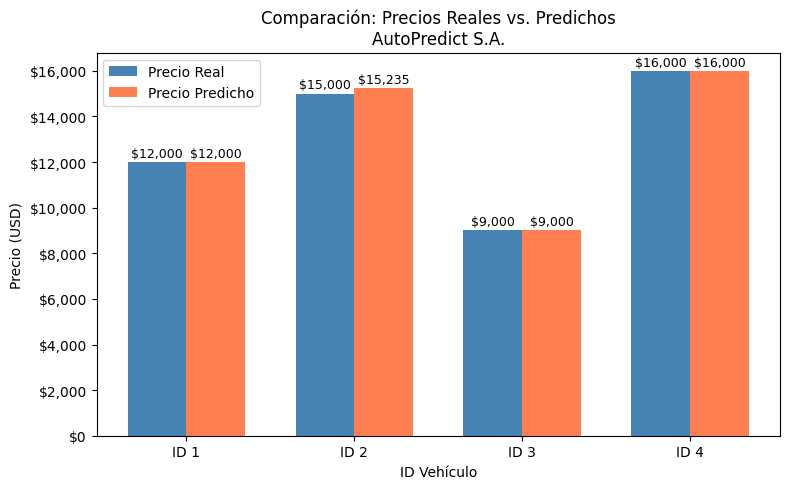

Gráfico guardado como 'comparacion_precios.png'


In [ ]:
ids = df.index + 1
x_pos = np.arange(len(ids))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x_pos - width/2, y, width, label='Precio Real',    color='steelblue')
bars2 = ax.bar(x_pos + width/2, y_pred_all, width, label='Precio Predicho', color='coral')

ax.set_xlabel('ID Vehículo')
ax.set_ylabel('Precio (USD)')
ax.set_title('Comparación: Precios Reales vs. Predichos\nAutoPredict S.A.')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'ID {i}' for i in ids])
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_precios.png', dpi=150)
plt.show()
print("Gráfico guardado como 'comparacion_precios.png'")    #definimos todos los elementos para hacer un gráfico de barras acorde a lo que necesitamos


6. Informe de Resultados

¿Qué tan preciso es el modelo?
-Se podría decir que el modelo es bastante preciso, pero no tenemos cómo definir si está sobreajustado por la baja cantidad de datos disponibles, por lo que no tenemos cómo saber si el modelo realmente generaliza.

¿Qué decisiones tomarías para mejorar su desempeño?
-Intentaría conseguir más datos, de modo que se pueda validar su capacidad de generalización. También, podríamos implementar validación cruzada, para verificar su desempeño de manera más adecuada, y, quizá buscaría más variables que puedan ser relevantes en una regresión como esta, y que son de fácil acceso.

